In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
def parse_conllu_flat(filepath):
    words = []
    tags = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line.startswith('#') or not line:
                continue
                
            parts = line.split('\t')
            if len(parts) > 3:
                words.append(parts[1])
                tags.append(parts[3]) 
                
    return words, tags

In [3]:
print("Loading Indonesian GSD datasets...")
train_words, train_tags = parse_conllu_flat('id_gsd-ud-train.conllu')
test_words, test_tags = parse_conllu_flat('id_gsd-ud-test.conllu')

print("\nVectorizing data with TfidfVectorizer...")
vectorizer = TfidfVectorizer(analyzer='word', token_pattern=r".+", lowercase=False)

X_train = vectorizer.fit_transform(train_words)
X_test = vectorizer.transform(test_words)

print(f"Vocabulary Size: {len(vectorizer.get_feature_names_out())}")

Loading Indonesian GSD datasets...

Vectorizing data with TfidfVectorizer...
Vocabulary Size: 19223


In [4]:
print("\nTraining Linear SVM (SVC)...")
model = LinearSVC(C=1.0, max_iter=2000, random_state=42)
model.fit(X_train, train_tags)


Training Linear SVM (SVC)...


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


In [5]:
print("Predicting on Test Set...")
y_pred = model.predict(X_test)

acc = accuracy_score(test_tags, y_pred)
print(f"\nAccuracy: {acc:.4f}")

print("\nClassification Report:")
print(classification_report(test_tags, y_pred, zero_division=0))

Predicting on Test Set...

Accuracy: 0.8882

Classification Report:
              precision    recall  f1-score   support

         ADJ       0.83      0.67      0.74       425
         ADP       0.96      0.96      0.96      1153
         ADV       0.85      0.81      0.83       490
         AUX       0.99      1.00      0.99        96
       CCONJ       0.99      0.90      0.94       375
         DET       0.94      0.93      0.94       374
        NOUN       0.92      0.79      0.85      2555
         NUM       0.92      0.79      0.85       407
        PART       0.92      0.94      0.93        49
        PRON       0.99      0.94      0.96       498
       PROPN       0.73      0.96      0.83      2211
       PUNCT       1.00      1.00      1.00      1724
       SCONJ       0.72      0.80      0.76       142
         SYM       1.00      1.00      1.00        30
        VERB       0.95      0.83      0.89      1250
           X       1.00      1.00      1.00         1

    accuracy

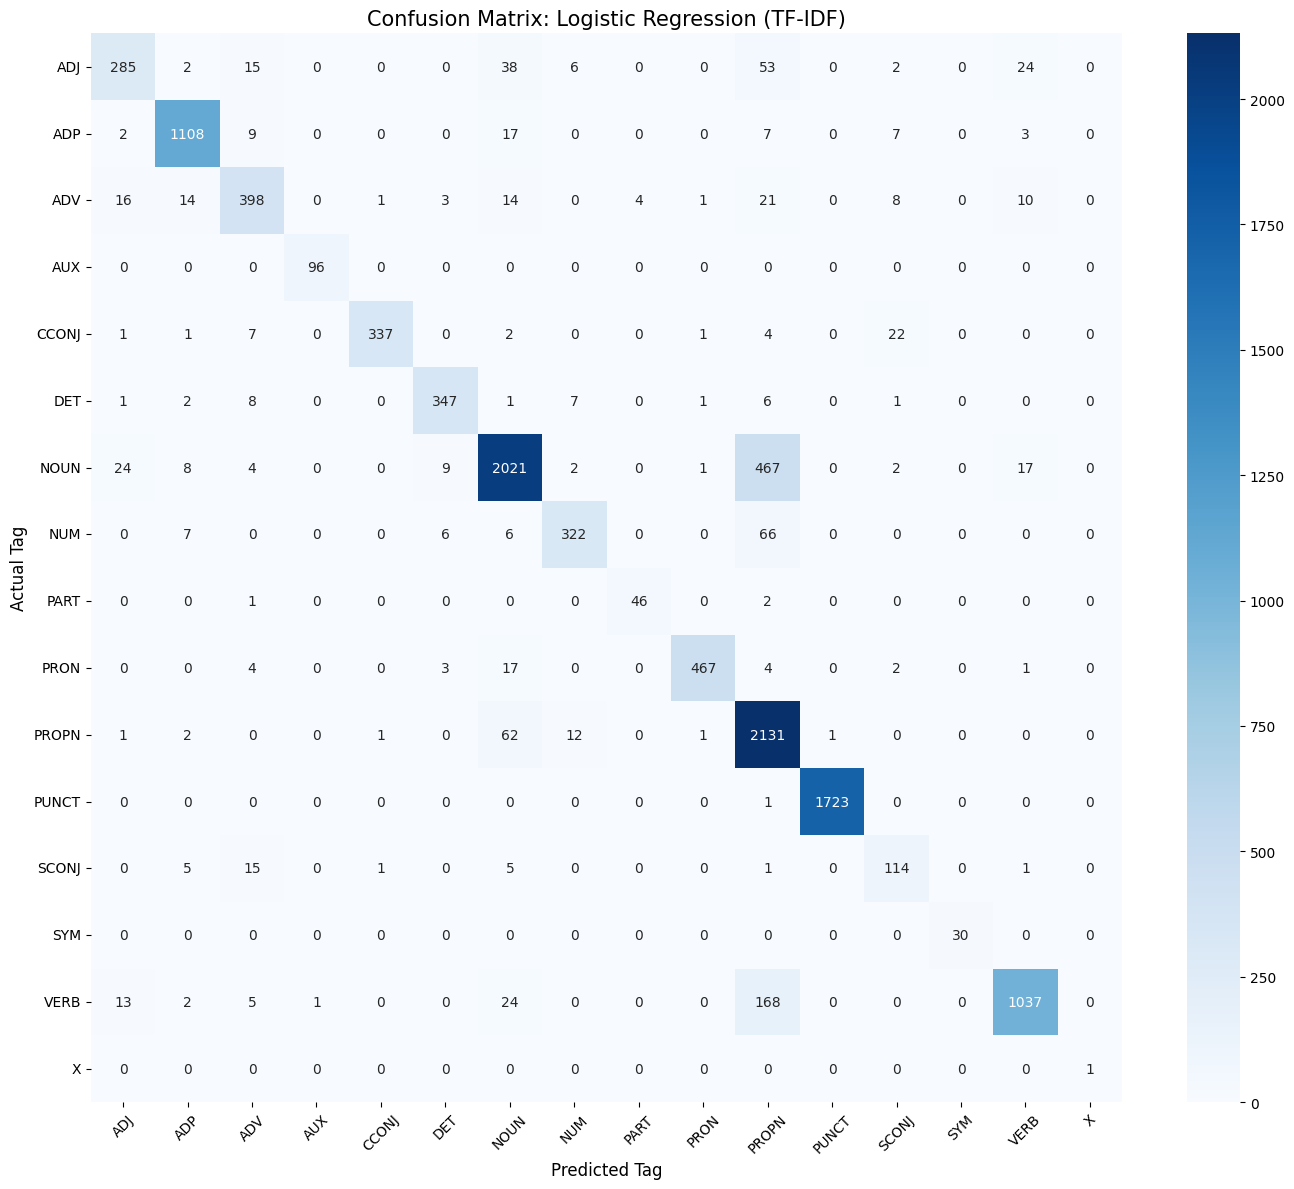

In [6]:
labels = sorted(list(set(test_tags)))
cm = confusion_matrix(test_tags, y_pred, labels=labels)

plt.figure(figsize=(14, 12))

_ = sns.heatmap(cm, 
            annot=True,         
            fmt='d',            
            cmap='Blues',       
            xticklabels=labels, 
            yticklabels=labels)

plt.xlabel('Predicted Tag', fontsize=12)
plt.ylabel('Actual Tag', fontsize=12)
plt.title('Confusion Matrix: Logistic Regression (TF-IDF)', fontsize=15)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()